<a href="https://colab.research.google.com/github/abishekkarkiiii/AI/blob/main/StudentMarks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import seaborn as sbn
import matplotlib.pyplot as plt

In [4]:
data=pd.read_csv("./DataSet/StudentsPerformance.csv")

In [11]:
data.describe()
data.shape

(1000, 8)

In [6]:
data.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [80]:
table = data[["math score", "reading score", "writing score","test preparation course"]]


In [71]:
table

,math score,reading score,writing score,test preparation course
0,72,72,74,none
1,69,90,88,completed
2,90,95,93,none
3,47,57,44,none
4,76,78,75,none
...,...,...,...,...
995,88,99,95,completed
996,62,55,55,none
997,59,71,65,completed
998,68,78,77,completed


In [8]:
table

,test preparation course,math score,reading score,writing score
0,none,72,72,74
1,completed,69,90,88
2,none,90,95,93
3,none,47,57,44
4,none,76,78,75
...,...,...,...,...
995,completed,88,99,95
996,none,62,55,55
997,completed,59,71,65
998,completed,68,78,77


In [9]:
table.drop_duplicates()

,test preparation course,math score,reading score,writing score
0,none,72,72,74
1,completed,69,90,88
2,none,90,95,93
3,none,47,57,44
4,none,76,78,75
...,...,...,...,...
995,completed,88,99,95
996,none,62,55,55
997,completed,59,71,65
998,completed,68,78,77


In [10]:
table.shape

(1000, 4)

<Axes: xlabel='test preparation course', ylabel='math score'>

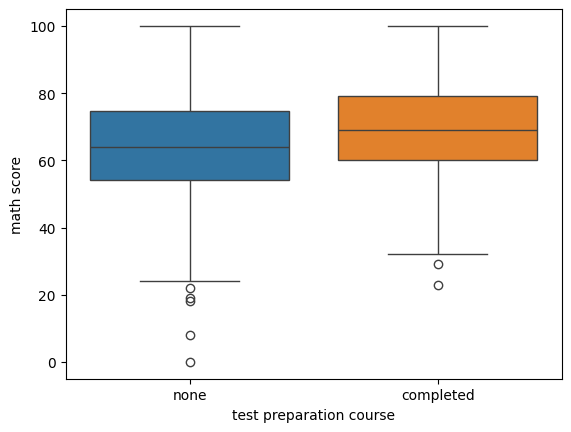

In [14]:

sbn.boxplot(data=table,x="test preparation course",y="math score",hue="test preparation course")

<Axes: xlabel='math score'>

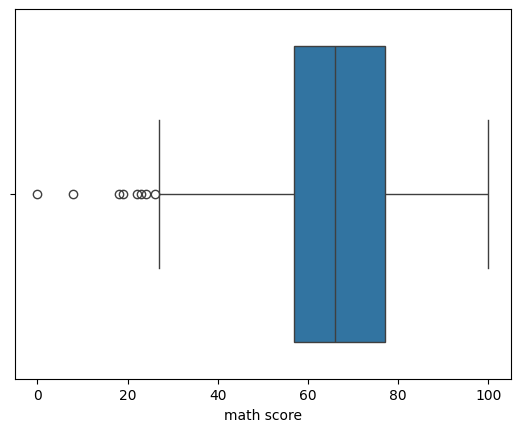

In [23]:
sbn.boxplot(x=table['math score'])

In [24]:
IQR=table['math score'].quantile(0.75)-table['math score'].quantile(0.25)

In [27]:
Q1=table['math score'].quantile(0.25)
Q3=table['math score'].quantile(0.75)


In [28]:
lower=Q1 - 1.5 * IQR
upper=Q3 + 1.5 * IQR

In [95]:
df=table
df_clean = df[
    (df["math score"] >= lower) &
    (df["math score"] <= upper)
]

In [96]:
df

,math score,reading score,writing score,test preparation course
0,72,72,74,none
1,69,90,88,completed
2,90,95,93,none
3,47,57,44,none
4,76,78,75,none
...,...,...,...,...
995,88,99,95,completed
996,62,55,55,none
997,59,71,65,completed
998,68,78,77,completed


In [97]:
df["test preparation course"] = df["test preparation course"].map({
    "none": 0,
    "completed": 1
})

/tmp/ipykernel_655/3844825777.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["test preparation course"] = df["test preparation course"].map({


In [98]:
df

,math score,reading score,writing score,test preparation course
0,72,72,74,0
1,69,90,88,1
2,90,95,93,0
3,47,57,44,0
4,76,78,75,0
...,...,...,...,...
995,88,99,95,1
996,62,55,55,0
997,59,71,65,1
998,68,78,77,1


<Axes: ylabel='Density'>

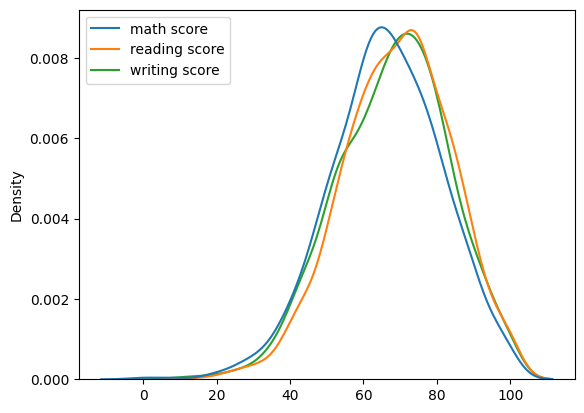

In [72]:
sbn.kdeplot(table)

In [89]:
df["math_group"] = pd.cut(
    df["math score"],
    bins=[0, 50, 75, 100],
    labels=["Low", "Medium", "High"]
)

/tmp/ipykernel_655/2058891268.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["math_group"] = pd.cut(


In [90]:
df['math_group']

,math_group
0,Medium
1,Medium
2,High
3,Low
4,High
...,...
995,High
996,Medium
997,Medium
998,Medium


<Axes: xlabel='reading score', ylabel='math score'>

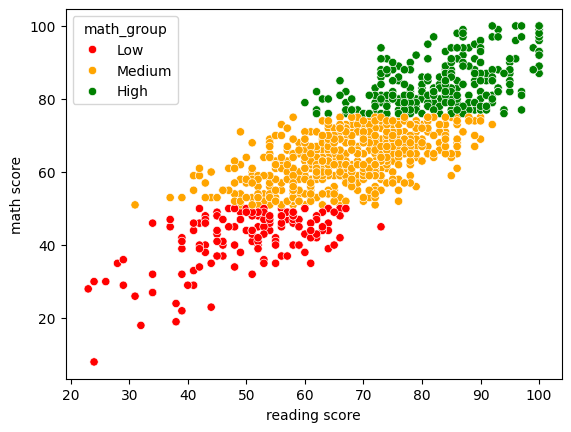

In [91]:
sbn.scatterplot(
    data=df,
    x="reading score",
    y="math score",
    hue="math_group",
    palette={
        "Low": "red",
        "Medium": "orange",
        "High": "green"
    }
)


<Axes: xlabel='writing score', ylabel='math score'>

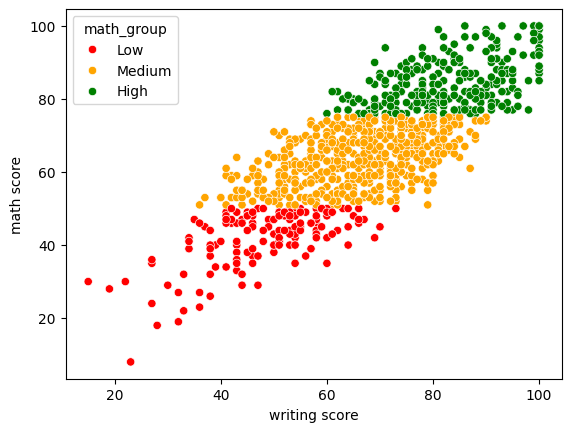

In [92]:
sbn.scatterplot(
    data=df,
    x="writing score",
    y="math score",
    hue="math_group",
    palette={
        "Low": "red",
        "Medium": "orange",
        "High": "green"
    }
)

In [81]:
table.head()

,math score,reading score,writing score,test preparation course
0,72,72,74,none
1,69,90,88,completed
2,90,95,93,none
3,47,57,44,none
4,76,78,75,none


In [93]:
df.head()

,math score,reading score,writing score,test preparation course,math_group
0,72,72,74,NaN,Medium
1,69,90,88,NaN,Medium
2,90,95,93,NaN,High
3,47,57,44,NaN,Low
4,76,78,75,NaN,High


In [108]:
X = df[["reading score", "writing score","test preparation course"]]
y = df["math score"]


In [109]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [110]:
model=LinearRegression().fit(X_train, y_train)

In [111]:
y_pred = model.predict(X_test)

In [113]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 7.31954594310432


In [106]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R²:", r2)

R²: 0.6867715640597238


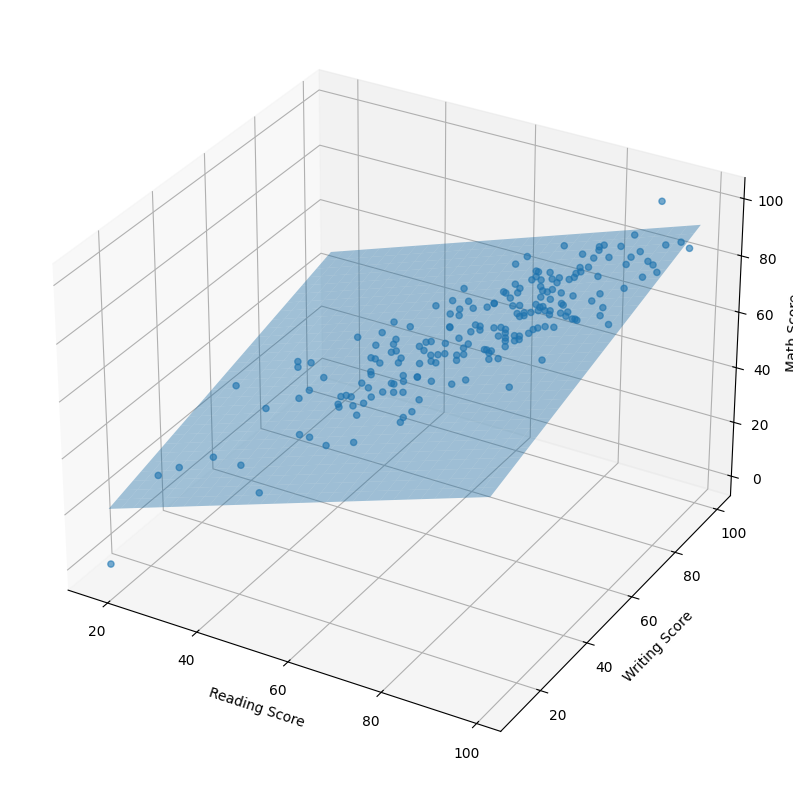

In [107]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection="3d")

# Actual data points
ax.scatter(
    X_test["reading score"],
    X_test["writing score"],
    y_test,
    alpha=0.6
)

# Create grid
reading = np.linspace(
    X_test["reading score"].min(),
    X_test["reading score"].max(),
    30
)

writing = np.linspace(
    X_test["writing score"].min(),
    X_test["writing score"].max(),
    30
)

R, W = np.meshgrid(reading, writing)

# Calculate predicted math score
Z = (
    model.intercept_
    + model.coef_[0] * R
    + model.coef_[1] * W
)

# Draw regression plane
ax.plot_surface(R, W, Z, alpha=0.4)

ax.set_xlabel("Reading Score")
ax.set_ylabel("Writing Score")
ax.set_zlabel("Math Score")

plt.show()

In [99]:
df

,math score,reading score,writing score,test preparation course
0,72,72,74,0
1,69,90,88,1
2,90,95,93,0
3,47,57,44,0
4,76,78,75,0
...,...,...,...,...
995,88,99,95,1
996,62,55,55,0
997,59,71,65,1
998,68,78,77,1


In [100]:
df.isnull().sum()

,0
math score,0
reading score,0
writing score,0
test preparation course,0
